# Spiking Neural Network (SNN) - TensorFlow / Keras


Loading data...
Encoding spikes... (This may take a moment and use RAM)

Building model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'SNN_MNIST', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "SNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lif_1 (LIFLayer)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lif_2 (LIFLayer)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8930 - loss: 0.4449 - val_accuracy: 0.9587 - val_loss: 0.1561
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9576 - loss: 0.1467 - val_accuracy: 0.9712 - val_loss: 0.1044
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9727 - loss: 0.0957 - val_accuracy: 0.9742 - val_loss: 0.0882
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9807 - loss: 0.0676 - val_accuracy: 0.9760 - val_loss: 0.0844
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9862 - loss: 0.0491 - val_accuracy: 0.9785 - val_loss: 0.0751
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9900 - loss: 0.0368 - val_accuracy: 0.9785 - val_loss: 0.0750
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9927 - loss: 0.0280 - val_accuracy: 0.9778 - val_loss: 0.0801
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9948 - los

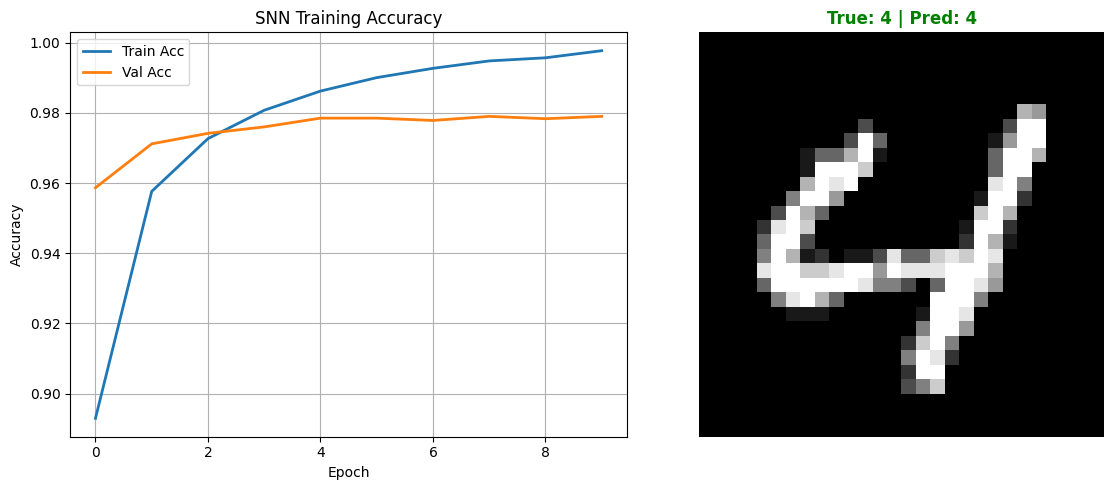

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD & PREPROCESS MNIST
# ============================================================

def load_mnist():
    """Loads MNIST, normalizes, flattens, and one-hot encodes labels."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32") / 255.0

    x_train = x_train.reshape(-1, 784)
    x_test  = x_test.reshape(-1, 784)

    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test  = tf.keras.utils.to_categorical(y_test, 10)

    return x_train, y_train, x_test, y_test

# ============================================================
# 2. SPIKE ENCODING (Poisson Rate Coding)
# ============================================================

def poisson_encode(data, timesteps=10):
    """
    Converts continuous pixel intensities into Poisson spike trains.
    Note: For large datasets, it's more memory efficient to apply this
    inside a tf.data.Dataset mapping rather than transforming the whole array.
    """
    data = tf.convert_to_tensor(data)
    encoded = []

    for _ in range(timesteps):
        spikes = tf.cast(tf.random.uniform(tf.shape(data)) < data, tf.float32)
        encoded.append(spikes)

    return tf.stack(encoded, axis=1)  # Shape: (batch, time, features)

# ============================================================
# 3. SURROGATE GRADIENT
# ============================================================

@tf.custom_gradient
def spike_fn(v_mem):
    """Forward pass: Step function. Backward pass: Fast Sigmoid surrogate."""
    spikes = tf.cast(v_mem >= 1.0, tf.float32)

    def grad(dy):
        # Surrogate gradient centered at threshold (1.0)
        return dy * tf.maximum(1.0 - tf.abs(v_mem - 1.0), 0.0)

    return spikes, grad

# ============================================================
# 4. LIF LAYER (TRAINABLE)
# ============================================================

class LIFLayer(tf.keras.layers.Layer):
    """Leaky Integrate-and-Fire Cell."""
    def __init__(self, units, decay=0.9, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.decay = decay
        self.dense = tf.keras.layers.Dense(units)

    def call(self, inputs, v_mem):
        # 1. Integrate incoming current
        current = self.dense(inputs)
        v_mem = self.decay * v_mem + current

        # 2. Check for spikes
        spikes = spike_fn(v_mem)

        # 3. Soft reset (subtract threshold if spiked)
        v_mem = v_mem - spikes

        return spikes, v_mem

# ============================================================
# 5. SNN MODEL ARCHITECTURE
# ============================================================

class SNN(tf.keras.Model):
    """2-Layer Spiking Neural Network."""
    def __init__(self, timesteps, **kwargs):
        super().__init__(**kwargs)
        self.timesteps = timesteps

        self.lif1 = LIFLayer(128, name="lif_1")
        self.lif2 = LIFLayer(64, name="lif_2")
        self.out  = tf.keras.layers.Dense(10, activation="softmax", name="output_dense")

    def call(self, x):
        batch_size = tf.shape(x)[0]

        # Initialize membrane potentials for the sequence
        v1 = tf.zeros([batch_size, self.lif1.units])
        v2 = tf.zeros([batch_size, self.lif2.units])

        spike_acc = tf.zeros([batch_size, self.lif2.units])

        # Unroll over time
        for t in range(self.timesteps):
            xt = x[:, t, :]

            s1, v1 = self.lif1(xt, v1)
            s2, v2 = self.lif2(s1, v2)

            spike_acc += s2

        # Average spikes over time for final classification
        out = spike_acc / tf.cast(self.timesteps, tf.float32)
        return self.out(out)

# ============================================================
# 6. MAIN EXECUTION (TRAIN & EVAL)
# ============================================================

def main():
    timesteps = 10

    print("Loading data...")
    x_train, y_train, x_test, y_test = load_mnist()

    print("Encoding spikes... (This may take a moment and use RAM)")
    x_train = poisson_encode(x_train, timesteps)
    x_test  = poisson_encode(x_test, timesteps)

    print("\nBuilding model...")
    model = SNN(timesteps, name="SNN_MNIST")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Build model to generate summary
    model.build(input_shape=(None, timesteps, 784))
    model.summary()

    print("\nTraining...")
    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.1
    )

    print("\nEvaluating on Test Set...")
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Final Test Accuracy: {acc:.4f}")

    # ============================================================
    # 7. VISUALIZATION
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- (A) Accuracy Curve
    axes[0].plot(history.history["accuracy"], label="Train Acc", linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Val Acc", linewidth=2)
    axes[0].set_title("SNN Training Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # ---- (B) Prediction Sample
    idx = np.random.randint(0, len(x_test))
    sample = x_test[idx:idx+1]

    pred = np.argmax(model.predict(sample, verbose=0))
    true = np.argmax(y_test[idx])

    # Sum spikes across the time dimension to visualize the rate-coded digit
    # Shape goes from (1, timesteps, 784) -> (784) -> (28, 28)
    img_to_show = np.sum(sample[0].numpy(), axis=0).reshape(28, 28)

    axes[1].imshow(img_to_show, cmap="gray")
    axes[1].set_title(
        f"True: {true} | Pred: {pred}",
        color="green" if true == pred else "red",
        fontweight="bold"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()